# Analisis Clustering Supply Chain: K-Means vs HDBSCAN

Notebook ini digunakan untuk membandingkan dua metode clustering:

1. **K-Means** sebagai metode pembanding.
2. **HDBSCAN** sebagai metode utama yang lebih advanced.

Evaluasi dilakukan menggunakan **Silhouette Score**.  
Model dengan nilai Silhouette Score terbaik akan dipilih sebagai model final untuk dashboard.


## 2. Import Library

In [134]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sqlalchemy import create_engine

import hdbscan


## 3. Koneksi Database dan Ambil Data

In [135]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="dwh_supply_chain"
)

query = "SELECT * FROM v_data_clustering_python"
df = pd.read_sql(query, conn)

df.head()


C:\Users\ardan\AppData\Local\Temp\ipykernel_21860\2487691696.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id_pergerakan,nama_produk,kategori,sub_kategori,merek,nama_pemasok,jenis_pemasok,kota,provinsi,departemen,peran,tanggal,bulan,tahun,jumlah_unit,biaya_pengiriman,waktu_siklus_hari,nilai_inventaris,jumlah_cacat
0,1,PRODUK_ELE_001,ELEKTRONIK,KOMPONEN,NUSA,PT PEMASOK 001,LOKAL,JAKARTA,DKI JAKARTA,GUDANG,STAF GUDANG,2024-01-01,Januari,2024,10,50000.0,1,151750.0,1
1,2,PRODUK_PAK_008,PAKAIAN,BAWAHAN,INTI,PT PEMASOK 010,PRODUSEN,BANDUNG,JAWA BARAT,LOGISTIK,KOORDINATOR LOGISTIK,2024-01-02,Januari,2024,13,64845.0,6,216450.0,12
2,3,PRODUK_RUM_015,RUMAH TANGGA,PERALATAN DAPUR,MAJU,PT PEMASOK 019,DISTRIBUTOR,SURABAYA,JAWA TIMUR,PROCUREMENT,ADMIN PEMBELIAN,2024-01-03,Januari,2024,16,79690.0,11,290000.0,7
3,4,PRODUK_MAK_022,MAKANAN,BAHAN BAKU,PRIMA,PT PEMASOK 028,INTERNASIONAL,SEMARANG,JAWA TENGAH,OPERASIONAL,SUPERVISOR OPERASIONAL,2024-01-04,Januari,2024,19,94535.0,16,372400.0,2
4,5,PRODUK_KES_029,KESEHATAN,ALAT MEDIS,BERKAH,PT PEMASOK 037,NASIONAL,YOGYAKARTA,DI YOGYAKARTA,QUALITY CONTROL,QC INSPECTOR,2024-01-05,Januari,2024,22,109380.0,21,463650.0,13


## 4. Cek Struktur Dataset

In [136]:
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

print("\nDaftar kolom:")
print(df.columns)

df.info()


Jumlah data: 500
Jumlah kolom: 19

Daftar kolom:
Index(['id_pergerakan', 'nama_produk', 'kategori', 'sub_kategori', 'merek',
       'nama_pemasok', 'jenis_pemasok', 'kota', 'provinsi', 'departemen',
       'peran', 'tanggal', 'bulan', 'tahun', 'jumlah_unit', 'biaya_pengiriman',
       'waktu_siklus_hari', 'nilai_inventaris', 'jumlah_cacat'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pergerakan      500 non-null    int64  
 1   nama_produk        500 non-null    object 
 2   kategori           500 non-null    object 
 3   sub_kategori       500 non-null    object 
 4   merek              500 non-null    object 
 5   nama_pemasok       500 non-null    object 
 6   jenis_pemasok      500 non-null    object 
 7   kota               500 non-null    object 
 8   provinsi           500 non-null    object 
 

## 5. Menentukan Variabel Clustering

Variabel yang digunakan untuk proses clustering adalah variabel numerik dari fact table:

- `jumlah_unit`
- `biaya_pengiriman`
- `waktu_siklus_hari`
- `nilai_inventaris`
- `jumlah_cacat`

Kolom seperti `nama_produk`, `kategori`, `kota`, `departemen`, `pemasok`, dan tanggal tidak digunakan dalam perhitungan cluster.  
Kolom tersebut hanya digunakan untuk interpretasi hasil dan dashboard.


In [137]:
features = [
    "jumlah_unit",
    "biaya_pengiriman",
    "waktu_siklus_hari",
    "nilai_inventaris",
    "jumlah_cacat"
]

X = df[features].copy()
X.head()


,jumlah_unit,biaya_pengiriman,waktu_siklus_hari,nilai_inventaris,jumlah_cacat
0,10,50000.0,1,151750.0,1
1,13,64845.0,6,216450.0,12
2,16,79690.0,11,290000.0,7
3,19,94535.0,16,372400.0,2
4,22,109380.0,21,463650.0,13


## 6. Cek Missing Value

In [138]:
X.isnull().sum()


jumlah_unit          0
biaya_pengiriman     0
waktu_siklus_hari    0
nilai_inventaris     0
jumlah_cacat         0
dtype: int64

## 7. Statistik Deskriptif Variabel Clustering

In [139]:
X.describe()


,jumlah_unit,biaya_pengiriman,waktu_siklus_hari,nilai_inventaris,jumlah_cacat
count,500.000000,5.000000e+02,500.000000,5.000000e+02,500.000000
mean,250.806000,5.098475e+05,13.460000,6.324185e+06,7.452000
std,143.981018,2.745573e+05,8.555395,3.921900e+06,4.612401
min,10.000000,5.000000e+04,1.000000,1.517500e+05,0.000000
25%,125.750000,2.706138e+05,6.000000,2.977238e+06,3.000000
50%,250.500000,4.872725e+05,11.000000,6.175538e+06,7.000000
75%,375.250000,7.442438e+05,21.000000,8.962800e+06,12.000000
max,500.000000,1.006045e+06,26.000000,1.596315e+07,15.000000


## 8. Standardisasi Data

Standardisasi dilakukan karena skala variabel berbeda jauh.

Contoh:
- `jumlah_cacat` memiliki nilai kecil.
- `nilai_inventaris` dan `biaya_pengiriman` memiliki nilai besar.

Tanpa standardisasi, variabel bernilai besar dapat terlalu mendominasi proses clustering.


In [140]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()


,jumlah_unit,biaya_pengiriman,waktu_siklus_hari,nilai_inventaris,jumlah_cacat
0,-1.674159,-1.676547,-1.457849,-1.575414,-1.400239
1,-1.653302,-1.622424,-0.872838,-1.558901,0.987025
2,-1.632445,-1.568301,-0.287826,-1.540128,-0.098095
3,-1.611589,-1.514178,0.297186,-1.519097,-1.183215
4,-1.590732,-1.460055,0.882198,-1.495807,1.204049


## 9. Evaluasi K-Means

K-Means digunakan sebagai metode pembanding.  
Jumlah cluster diuji dari 2 sampai 6, kemudian dievaluasi menggunakan Silhouette Score.


In [141]:
kmeans_results = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    kmeans_results.append({
        "model": "K-Means",
        "jumlah_cluster": k,
        "silhouette_score": score
    })

kmeans_df = pd.DataFrame(kmeans_results)
kmeans_df


,model,jumlah_cluster,silhouette_score
0,K-Means,2,0.252095
1,K-Means,3,0.216535
2,K-Means,4,0.192142
3,K-Means,5,0.206785
4,K-Means,6,0.208423


## 10. Evaluasi HDBSCAN

HDBSCAN tidak membutuhkan jumlah cluster di awal.  
Namun, performanya dipengaruhi oleh parameter:

- `min_cluster_size`
- `min_samples`

Nilai `-1` pada hasil HDBSCAN berarti data dianggap sebagai **noise/outlier**.


In [142]:
hdbscan_results = []

min_cluster_sizes = [5, 10, 15, 20, 25, 30, 40, 50]
min_samples_values = [2, 3, 5, 10, 15]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        model = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        mask = labels != -1
        jumlah_cluster = len(set(labels[mask]))
        jumlah_noise = list(labels).count(-1)

        if jumlah_cluster > 1:
            score = silhouette_score(X_scaled[mask], labels[mask])
        else:
            score = np.nan

        hdbscan_results.append({
            "model": "HDBSCAN",
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "jumlah_cluster": jumlah_cluster,
            "jumlah_noise": jumlah_noise,
            "silhouette_score": score
        })

hdbscan_df = pd.DataFrame(hdbscan_results)
hdbscan_df.sort_values(by="silhouette_score", ascending=False).head(15)


,model,min_cluster_size,min_samples,jumlah_cluster,jumlah_noise,silhouette_score
24,HDBSCAN,25,15,2,152,0.257737
29,HDBSCAN,30,15,2,152,0.257737
39,HDBSCAN,50,15,2,152,0.257737
34,HDBSCAN,40,15,2,152,0.257737
19,HDBSCAN,20,15,2,152,0.257737
14,HDBSCAN,15,15,2,152,0.257737
37,HDBSCAN,50,5,2,12,0.250400
33,HDBSCAN,40,10,2,99,0.242324
38,HDBSCAN,50,10,2,99,0.242324
28,HDBSCAN,30,10,3,69,0.210332


## 11. Ambil Konfigurasi HDBSCAN Terbaik

In [143]:
best_hdbscan = hdbscan_df.sort_values(
    by="silhouette_score",
    ascending=False
).iloc[0]

best_hdbscan


model                HDBSCAN
min_cluster_size          25
min_samples               15
jumlah_cluster             2
jumlah_noise             152
silhouette_score    0.257737
Name: 24, dtype: object

## 12. Perbandingan K-Means dan HDBSCAN

K-Means terbaik dibandingkan dengan HDBSCAN terbaik berdasarkan Silhouette Score.


In [144]:
best_kmeans = kmeans_df.sort_values(
    by="silhouette_score",
    ascending=False
).iloc[0]

comparison = pd.DataFrame([
    {
        "model": "K-Means",
        "parameter": f"k={int(best_kmeans['jumlah_cluster'])}",
        "jumlah_cluster": int(best_kmeans["jumlah_cluster"]),
        "jumlah_noise": 0,
        "silhouette_score": best_kmeans["silhouette_score"]
    },
    {
        "model": "HDBSCAN",
        "parameter": f"min_cluster_size={int(best_hdbscan['min_cluster_size'])}, min_samples={int(best_hdbscan['min_samples'])}",
        "jumlah_cluster": int(best_hdbscan["jumlah_cluster"]),
        "jumlah_noise": int(best_hdbscan["jumlah_noise"]),
        "silhouette_score": best_hdbscan["silhouette_score"]
    }
])

comparison


,model,parameter,jumlah_cluster,jumlah_noise,silhouette_score
0,K-Means,k=2,2,0,0.252095
1,HDBSCAN,"min_cluster_size=25, min_samples=15",2,152,0.257737


## 13. Visualisasi Perbandingan Silhouette Score

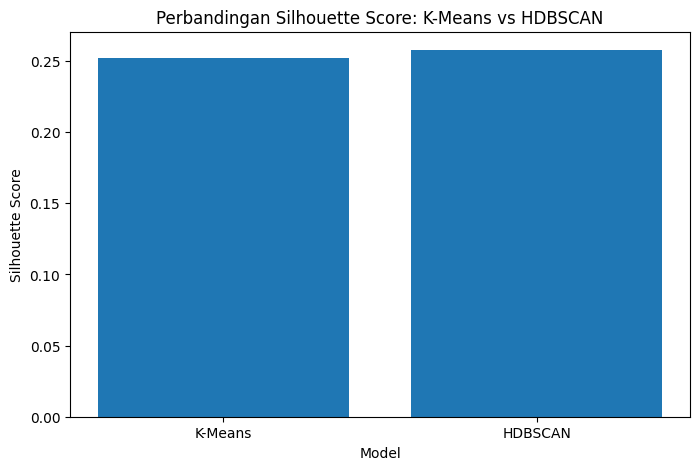

In [145]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["model"],
    comparison["silhouette_score"]
)

plt.title("Perbandingan Silhouette Score: K-Means vs HDBSCAN")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.show()


## 14. Menentukan Model Terbaik

Model terbaik dipilih berdasarkan nilai Silhouette Score tertinggi.


In [146]:
best_model = comparison.sort_values(
    by="silhouette_score",
    ascending=False
).iloc[0]

print("Model terbaik:", best_model["model"])
print("Parameter:", best_model["parameter"])
print("Jumlah cluster:", best_model["jumlah_cluster"])
print("Jumlah noise:", best_model["jumlah_noise"])
print("Silhouette Score:", best_model["silhouette_score"])


Model terbaik: HDBSCAN
Parameter: min_cluster_size=25, min_samples=15
Jumlah cluster: 2
Jumlah noise: 152
Silhouette Score: 0.25773749307106286


## 15. Jalankan Model Terbaik

In [147]:
if best_model["model"] == "K-Means":
    best_k = int(best_kmeans["jumlah_cluster"])

    final_model = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    )

    df["cluster"] = final_model.fit_predict(X_scaled)
    df["is_noise"] = 0

else:
    final_model = hdbscan.HDBSCAN(
        min_cluster_size=int(best_hdbscan["min_cluster_size"]),
        min_samples=int(best_hdbscan["min_samples"])
    )

    labels = final_model.fit_predict(X_scaled)
    df["cluster"] = labels
    df["is_noise"] = (labels == -1).astype(int)

df[["id_pergerakan", "cluster", "is_noise"]].head()


,id_pergerakan,cluster,is_noise
0,1,-1,1
1,2,-1,1
2,3,-1,1
3,4,-1,1
4,5,-1,1


In [148]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin

labels = df["cluster"].values.copy()

mask_noise = labels == -1
mask_cluster = labels != -1

centroids = []

for c in sorted(set(labels[mask_cluster])):
    centroids.append(X_scaled[labels == c].mean(axis=0))

centroids = np.array(centroids)

nearest_cluster = pairwise_distances_argmin(
    X_scaled[mask_noise],
    centroids
)

cluster_names = sorted(set(labels[mask_cluster]))

labels[mask_noise] = [cluster_names[i] for i in nearest_cluster]

# Update hasil clustering
df["cluster"] = labels
df["is_noise"] = 0

# Berikan label bisnis pada cluster
cluster_labels = {
    0: "Produk dengan Aktivitas Supply Chain Rendah",
    1: "Produk dengan Aktivitas Supply Chain Tinggi"
}

df["cluster_label"] = df["cluster"].map(cluster_labels)

df["cluster"].value_counts()

cluster
1    288
0    212
Name: count, dtype: int64

## 16. Jumlah Data Tiap Cluster

In [149]:
cluster_count = df["cluster"].value_counts().sort_index()
cluster_count


cluster
0    212
1    288
Name: count, dtype: int64

## 17. Persentase Data Tiap Cluster

In [150]:
cluster_percentage = (cluster_count / len(df) * 100).round(2)
cluster_percentage


cluster
0    42.4
1    57.6
Name: count, dtype: float64

## 18. Karakteristik Tiap Cluster

Bagian ini digunakan untuk melihat rata-rata setiap variabel pada masing-masing cluster.

Jika terdapat cluster `-1`, artinya data tersebut adalah noise/outlier hasil HDBSCAN.


In [151]:
cluster_summary = df.groupby("cluster")[features].mean()
cluster_summary


,jumlah_unit,biaya_pengiriman,waktu_siklus_hari,nilai_inventaris,jumlah_cacat
cluster,,,,,
0,108.070755,562032.405660,13.358491,2.688985e+06,7.575472
1,355.875000,471433.611111,13.534722,9.000096e+06,7.361111


## 19. Penamaan Cluster

Nama cluster tidak otomatis dihasilkan oleh algoritma.  
Nama cluster harus ditentukan berdasarkan karakteristik rata-rata pada `cluster_summary`.

Contoh:
- Cluster dengan unit dan inventaris rendah → Operasional Skala Rendah
- Cluster dengan unit dan inventaris tinggi → Operasional Intensif
- Cluster dengan biaya dan cacat tinggi → Prioritas Pengendalian
- Cluster `-1` pada HDBSCAN → Noise / Outlier


In [152]:
cluster_labels = {
    0: "Produk dengan Aktivitas Supply Chain Rendah",
    1: "Produk dengan Aktivitas Supply Chain Tinggi"
}

# Jika suatu saat ada noise
if -1 in df["cluster"].unique():
    cluster_labels[-1] = "Noise / Outlier"

df["cluster_label"] = df["cluster"].map(cluster_labels)

df[["id_pergerakan", "cluster", "cluster_label"]].head()

,id_pergerakan,cluster,cluster_label
0,1,0,Produk dengan Aktivitas Supply Chain Rendah
1,2,0,Produk dengan Aktivitas Supply Chain Rendah
2,3,0,Produk dengan Aktivitas Supply Chain Rendah
3,4,0,Produk dengan Aktivitas Supply Chain Rendah
4,5,0,Produk dengan Aktivitas Supply Chain Rendah


In [154]:
df[["cluster", "cluster_label"]] \
    .drop_duplicates() \
    .sort_values("cluster") \
    .reset_index(drop=True)

,cluster,cluster_label
0,0,Produk dengan Aktivitas Supply Chain Rendah
1,1,Produk dengan Aktivitas Supply Chain Tinggi


## 20. Visualisasi Jumlah Data Tiap Cluster

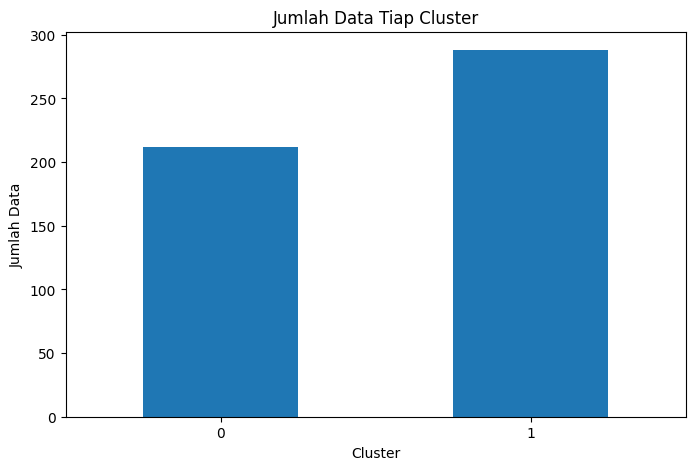

In [155]:
plt.figure(figsize=(8, 5))

cluster_count.plot(kind="bar")

plt.title("Jumlah Data Tiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()


## 21. Scatter Plot: Jumlah Unit vs Nilai Inventaris

Visualisasi ini digunakan karena `jumlah_unit` dan `nilai_inventaris` mudah dipahami secara bisnis.


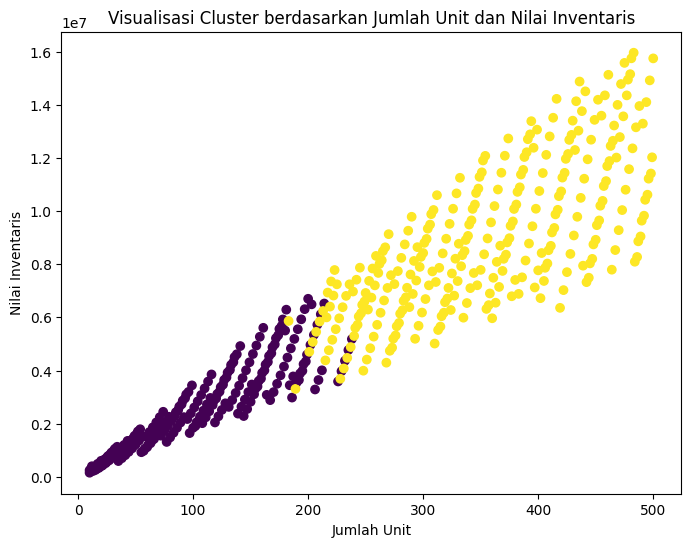

In [156]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["jumlah_unit"],
    df["nilai_inventaris"],
    c=df["cluster"]
)

plt.title("Visualisasi Cluster berdasarkan Jumlah Unit dan Nilai Inventaris")
plt.xlabel("Jumlah Unit")
plt.ylabel("Nilai Inventaris")
plt.show()


## 22. Visualisasi dengan PCA

Karena clustering dilakukan menggunakan 5 variabel, PCA digunakan untuk menampilkan hasil cluster dalam 2 dimensi.


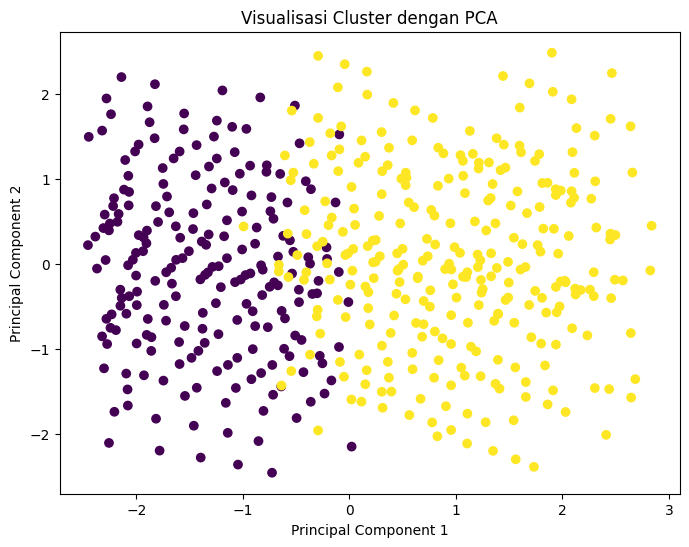

Explained variance ratio: [0.38678444 0.22258772]
Total informasi yang dijelaskan: 0.6093721605733666


In [157]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"]
)

plt.title("Visualisasi Cluster dengan PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total informasi yang dijelaskan:", pca.explained_variance_ratio_.sum())


In [158]:
print(df[["cluster", "cluster_label"]].drop_duplicates().sort_values("cluster"))

    cluster                                cluster_label
0         0  Produk dengan Aktivitas Supply Chain Rendah
69        1  Produk dengan Aktivitas Supply Chain Tinggi


## 23. Simpan Hasil Clustering ke MySQL

Hasil clustering final disimpan ke tabel `hasil_clustering`.

Dashboard dapat mengambil data dari tabel ini.


In [159]:
engine = create_engine("mysql+mysqlconnector://root:@localhost/dwh_supply_chain")

df.to_sql(
    "hasil_clustering",
    con=engine,
    if_exists="replace",
    index=False
)

print("Hasil clustering berhasil disimpan ke tabel hasil_clustering")


Hasil clustering berhasil disimpan ke tabel hasil_clustering


## 24.Kesimpulan 


Berdasarkan hasil perbandingan antara K-Means dan HDBSCAN menggunakan Silhouette Score, diperoleh bahwa model terbaik adalah **[nama model]** dengan nilai Silhouette Score sebesar **[nilai score]**. Model tersebut dipilih karena menghasilkan pemisahan cluster yang lebih baik dibandingkan model pembanding.

Jika model terbaik adalah HDBSCAN, maka data dengan label `-1` diinterpretasikan sebagai noise atau outlier.
